# IT-DPC - Surface Rainfall Intensity over Italy

This notebook describes how to access and use the zarr-version of the Italian [DPC SRI](https://dpc-radar.readthedocs.io/it/latest/index.html) dataset. The dataset includes 5-minute Surface Rainfall Intensity (SRI) measurements in mm/h at 1 km x 1 km spatial resolution over Italy, derived from the national radar network (23 radars) operated by the Italian Department of Civil Protection (Dipartimento Protezione Civile). The `v0.1.0` zarr version of the dataset covers **2010 to the end of 2025**.

The conversion of the radar data was done by the code hosted on [https://github.com/mlcast-community/mlcast-dataset-IT-DPC-SRI](https://github.com/mlcast-community/mlcast-dataset-IT-DPC-SRI).

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import mlcast_datasets

In [2]:
cat = mlcast_datasets.open_catalog()
list(cat.precipitation)

['radklim_hourly',
 'radklim_5_minutes',
 'dmi_10_minutes',
 'it_dpc_sri_5min',
 'uk_metoffice_5min',
 'be_rmi_radclim_mfb_5min']


# IT-DPC 5-min Surface Rainfall Intensity

The Italian DPC SRI dataset is available in the intake catalog as `it_dpc_sri_5min`.

In [3]:
ds = cat.precipitation.it_dpc_sri_5min.to_dask()
ds

<xarray.Dataset> Size: 7TB
Dimensions:        (time: 1039785, y: 1400, x: 1200, missing_times: 15530)
Coordinates:
  * time           (time) datetime64[ns] 8MB 2010-01-01 ... 2025-12-31T23:55:00
  * y              (y) float64 11kB 6.495e+05 6.485e+05 ... -7.495e+05
  * x              (x) float64 10kB -5.995e+05 -5.985e+05 ... 5.995e+05
    lat            (y, x) float64 13MB dask.array<chunksize=(1400, 1200), meta=np.ndarray>
    lon            (y, x) float64 13MB dask.array<chunksize=(1400, 1200), meta=np.ndarray>
  * missing_times  (missing_times) datetime64[ns] 124kB 2010-01-03T00:30:00 ....
Data variables:
    RR             (time, y, x) float32 7TB dask.array<chunksize=(1, 1400, 1200), meta=np.ndarray>
    crs            float32 4B ...
Attributes: (12/13)
    Author:                     Gabriele Franch
    Copyright:                  Dipartimento Protezione Civile (DPC) Nazional...
    Processed by:               Fondazione Bruno Kessler
    base_frequencies:           15min:2010-01-01T00:00/2014-06-25T09:00;10min...
    consistent_timestep_start:  2020-06-30T00:00
    history:                    Created at 2026-02-11T18:15:05+01:00
    ...                         ...
    mlcast_created_by:          Gabriele Franch <franch@fbk.eu>
    mlcast_created_on:          2026-02-11T18:15:05+01:00
    mlcast_created_with:        https://github.com/mlcast-community/mlcast-da...
    mlcast_dataset_identifier:  IT-DPC-SRI
    mlcast_dataset_version:     0.1.0
    title:                      Italian Radar DPC Surface Rainfall Intensity ...

/tmp/ipykernel_2649/891365573.py:21: FutureWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in g.axes.flat:


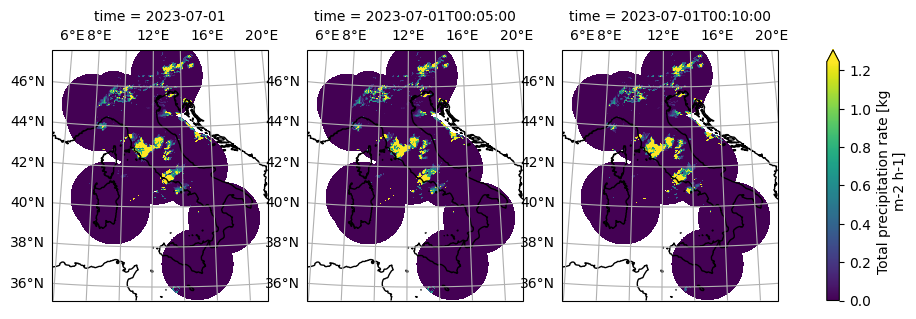

In [4]:
var_name = "RR"

crs_name = ds[var_name].grid_mapping
data_crs = ccrs.Projection(ds[crs_name].crs_wkt)

g = (
    ds[var_name]
    .sel(time="2023-07-01")
    .isel(time=slice(None, 3))
    .plot(
        transform=data_crs,
        cmap="viridis",
        add_colorbar=True,
        col="time",
        robust=True,
        subplot_kws=dict(projection=data_crs),
        vmin=0,
    )
)

for ax in g.axes.flat:
    ax.coastlines()
    ax.gridlines(draw_labels=["top", "left"])